In [469]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import pathlib
import seaborn as sns


from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error


from seaborn import set_style
set_style("whitegrid")

In [470]:
# Source - https://stackoverflow.com/a/50051542
# Posted by Aaron Brock, modified by community. See post 'Timeline' for change history
# Retrieved 2026-02-26, License - CC BY-SA 3.0

def to_csv(df, path):
    # Prepend dtypes to the top of df (from https://stackoverflow.com/a/43408736/7607701)
    df.loc[-1] = df.dtypes
    df.index = df.index + 1
    df.sort_index(inplace=True)
    # Then save it to a csv
    df.to_csv(path, index=False)

def read_csv(path):
    # Read types first line of csv
    dtypes = {key:value for (key,value) in pd.read_csv(path,    
              nrows=1).iloc[0].to_dict().items() if 'date' not in value}

    parse_dates = [key for (key,value) in pd.read_csv(path, 
                   nrows=1).iloc[0].to_dict().items() if 'date' in value]
    # Read the rest of the lines with the types from above
    return pd.read_csv(path, dtype=dtypes, parse_dates=parse_dates, skiprows=[1])

In [471]:
#Read in the combined weather/schedule/summary files for each sunday time period and combine them into a single dataframe 

loc = '../data/clean_data/'

csv_file_names = [loc+file for file in os.listdir(loc) if file.startswith('schedule_weather_sunday_period')]
list_of_dataframes = [read_csv(file) 
    for file in csv_file_names]
sun_df = pd.concat(list_of_dataframes, ignore_index=True)

In [472]:
# List the features we want to keep, sort them by their dtypes
cat_features = [
    'time_period',
    'EB/WB',  
    'Interruption',
    'conditions',
    #'pop',     
    #'pop_category',            
    #'wind_direction'        
]

num_features = [
    #'time_period',
    'bunch',
    #'EB/WB', 
    'gap', 
    #'No. of Veh', 
    #'Avg. spd (km/h)',
    #'Interruption',
    #'conditions',
    #'pop',     
    #'pop_category',   
    'temperature',         
    #'wind_direction',        
    #'wind_speed'
    ]

features = num_features + cat_features
# For the next (real) model, need to sort the types of features into numeric/categorical

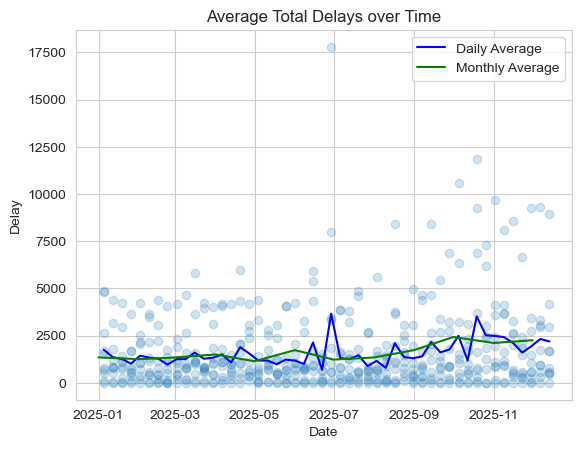

In [473]:
# Lets look at the average total delay for each day and for each month to check for seasonal trends 
plt.scatter(sun_df['date'], sun_df['total delay'], alpha=0.2)

# daily average
daily_avg = (
    sun_df
    .groupby('date')['total delay']
    .mean()
    .reset_index()
)

plt.plot(
    daily_avg['date'],
    daily_avg['total delay'],
    color='blue',
    label="Daily Average"
)

# monthly average
sun_df['month'] = sun_df['date'].dt.to_period('M')

monthly_avg = (
    sun_df
    .groupby('month')['total delay']
    .mean()
    .reset_index()
)

monthly_avg['month'] = monthly_avg['month'].dt.to_timestamp()

plt.plot(
    monthly_avg['month'],
    monthly_avg['total delay'],
    color='green',
    label="Monthly Average"
)

plt.xlabel("Date")
plt.ylabel("Delay")
plt.title("Average Total Delays over Time")
plt.legend()

plt.show()

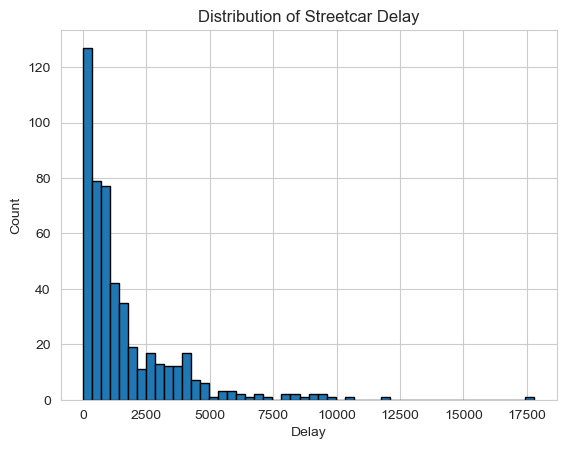

In [474]:
# Lets look at histograms for the target (total delay) and then for each of the numerical features
plt.hist(sun_df['total delay'], bins=50, edgecolor='black')
plt.title("Distribution of Streetcar Delay")
plt.xlabel("Delay")
plt.ylabel("Count")
plt.show()

## Based on this distribution, it looks like a lot of the delays are pretty short 

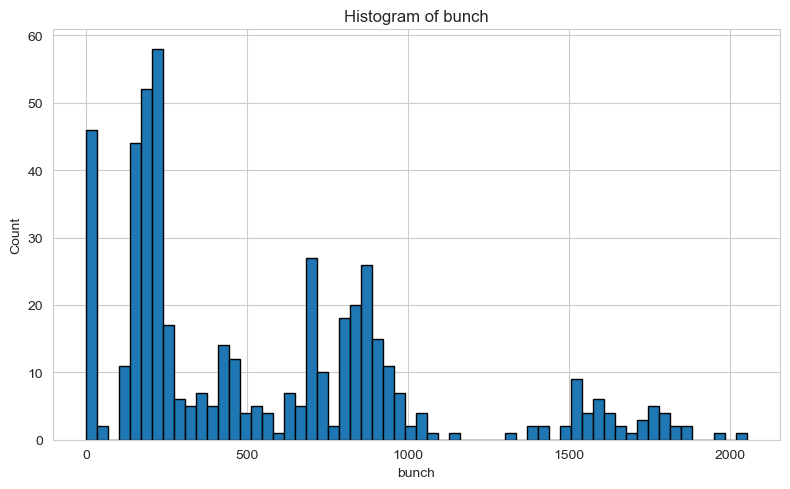

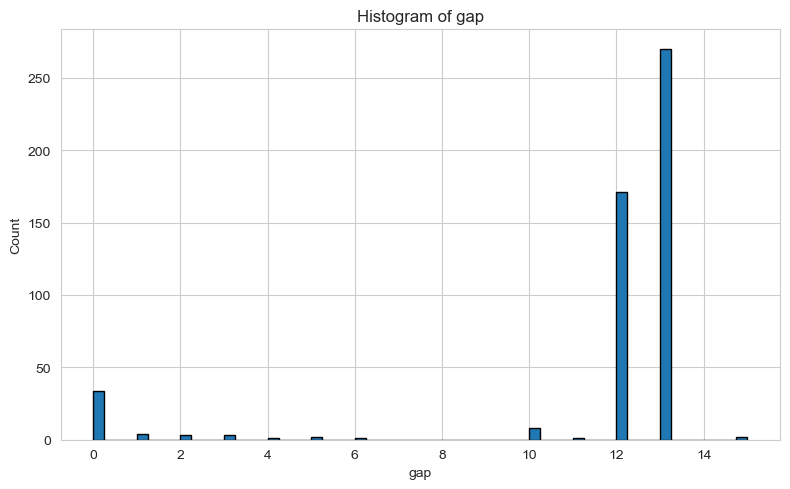

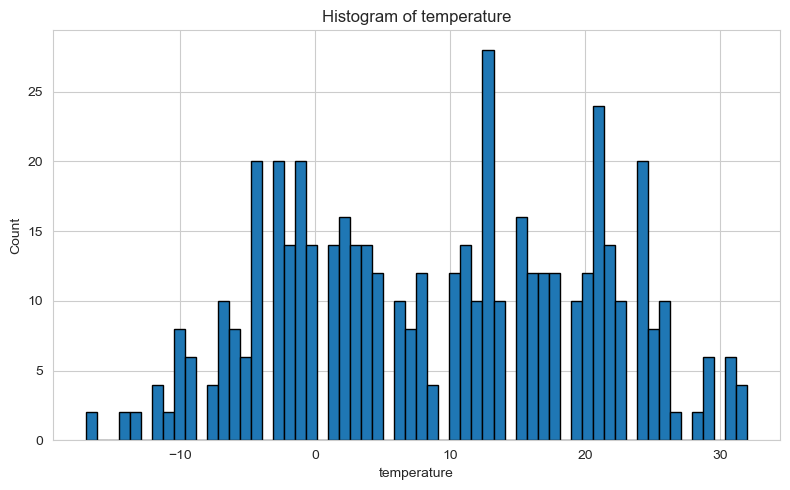

In [475]:
for col in num_features:
    plt.figure(figsize=(8, 5))
    plt.hist(sun_df[col], bins=60, edgecolor="black")
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
    plt.close()

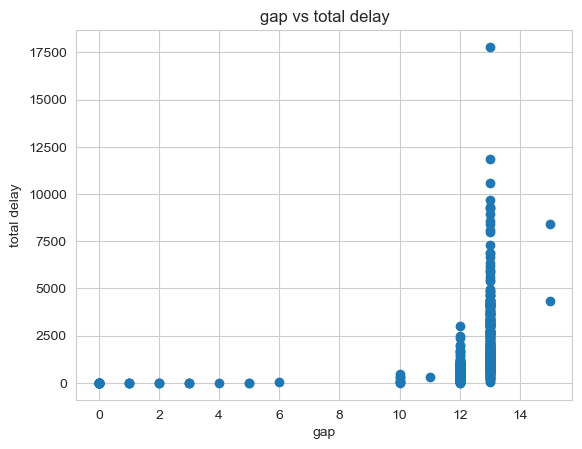

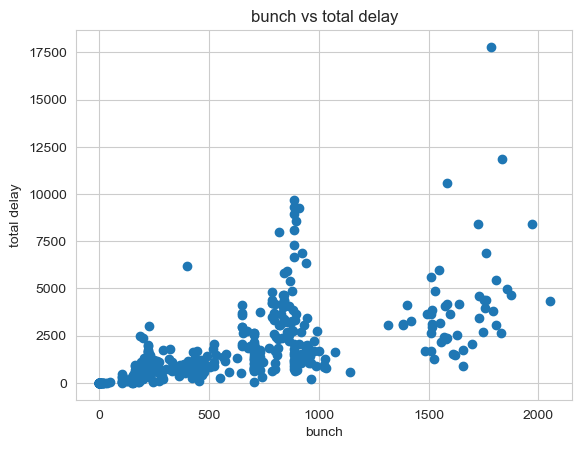

In [476]:
# Gap and Bunch are both clustering towards higher and lower values respectively so lets look at each of these compared to the total delay time and also compare to one another.
# Lets look at the gap vs total delay first 
plt.scatter(sun_df['gap'], sun_df['total delay'])
plt.xlabel("gap")
plt.ylabel("total delay")
plt.title("gap vs total delay")
plt.show()

plt.scatter(sun_df['bunch'], sun_df['total delay'])
plt.xlabel("bunch")
plt.ylabel("total delay")
plt.title("bunch vs total delay")
plt.show()

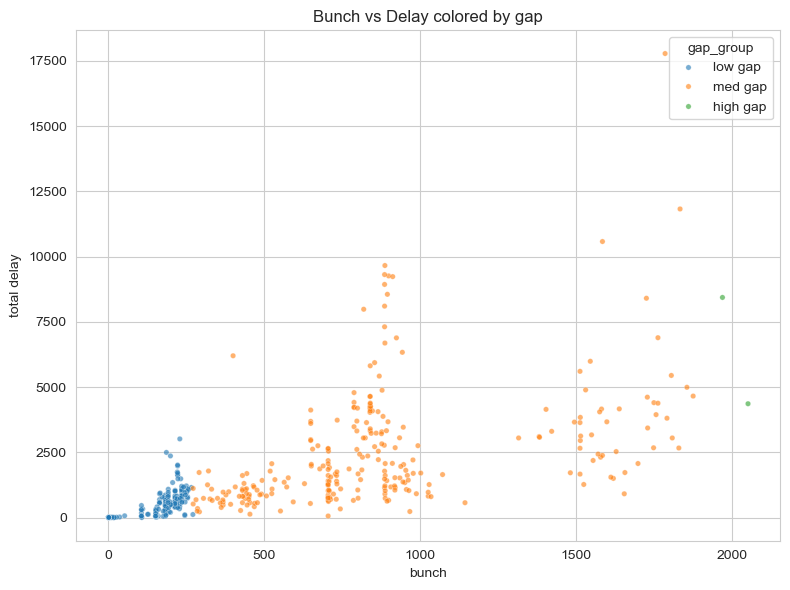

In [495]:
# Looking at bunch vs total delay we color by the gap and see a lot of clustering depending on what the gap is so lets group the gaps into different categories and then compare
sun_df["gap_group"] = pd.qcut(
    sun_df["gap"],
    3,
    labels=["low gap", "med gap", "high gap"]
)
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=sun_df,
    x="bunch",
    y="total delay",
    hue="gap_group",
    #palette="tab20",
    alpha=0.6,
    s=15
    )
#plt.xscale("log")
#plt.yscale("log")
plt.title("Bunch vs Delay colored by gap")
plt.xlabel("bunch")
plt.ylabel("total delay")

plt.tight_layout()
plt.show()
plt.close()

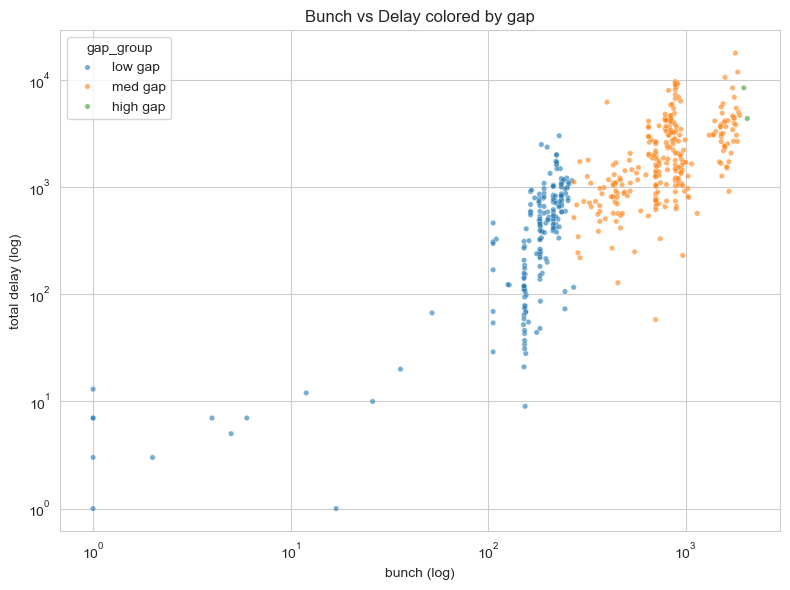

In [496]:
# Looking at bunch vs total delay we color by the gap and see a lot of clustering depending on what the gap is so lets group the gaps into different categories and then compare
sun_df["gap_group"] = pd.qcut(
    sun_df["gap"],
    3,
    labels=["low gap", "med gap", "high gap"]
)
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=sun_df,
    x="bunch",
    y="total delay",
    hue="gap_group",
    #palette="tab20",
    alpha=0.6,
    s=15
    )
plt.xscale("log")
plt.yscale("log")
plt.title("Bunch vs Delay colored by gap")
plt.xlabel("bunch (log)")
plt.ylabel("total delay (log)")

plt.tight_layout()
plt.show()
plt.close()

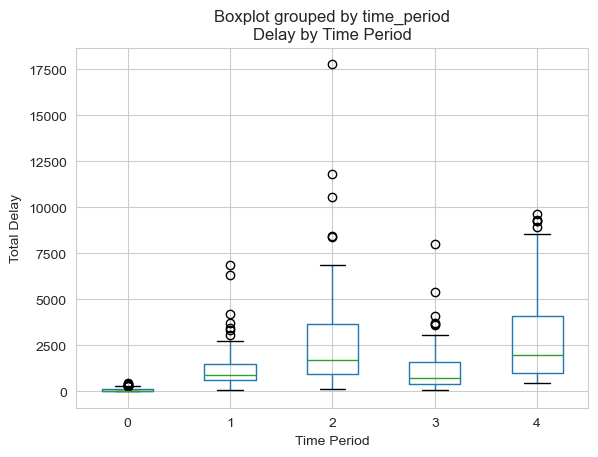

In [478]:
#Compare the total delay time across each time period
sun_df.boxplot(column='total delay', by='time_period')
plt.title("Delay by Time Period")
plt.xlabel("Time Period")
plt.ylabel("Total Delay")
plt.show()

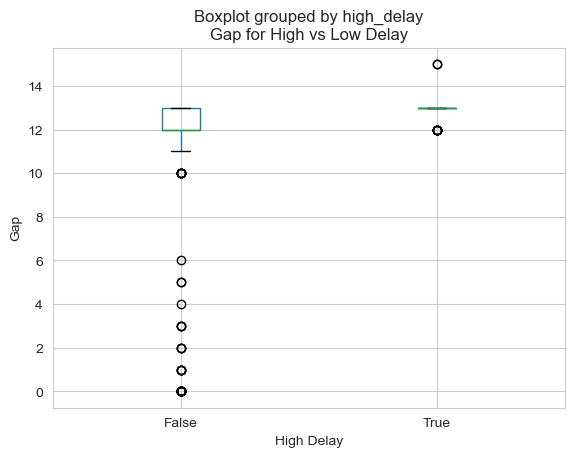

In [479]:
# Compare the values of gap for high delay times (greater than mean) vs low delay times
sun_df['high_delay'] = sun_df['total delay'] > sun_df['total delay'].mean()

sun_df.boxplot(column='gap', by='high_delay')
plt.title("Gap for High vs Low Delay")
plt.xlabel("High Delay")
plt.ylabel("Gap")
plt.show()

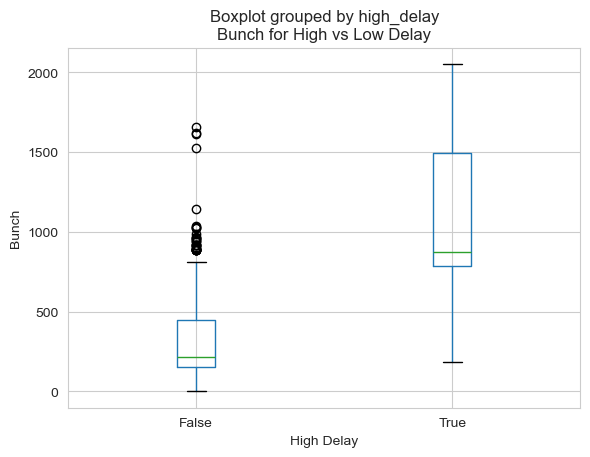

In [480]:
# Interesting, this seems to have pretty different behavior. Lets do the same for bunching for high delay times vs low delay 
sun_df['high_delay'] = sun_df['total delay'] > sun_df['total delay'].mean()

sun_df.boxplot(column='bunch', by='high_delay')
plt.title("Bunch for High vs Low Delay")
plt.xlabel("High Delay")
plt.ylabel("Bunch")
plt.show()

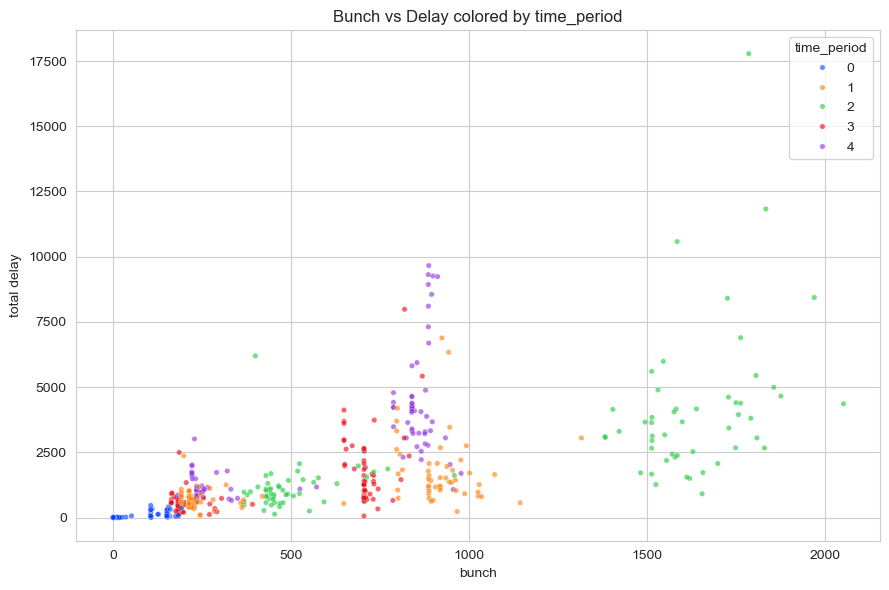

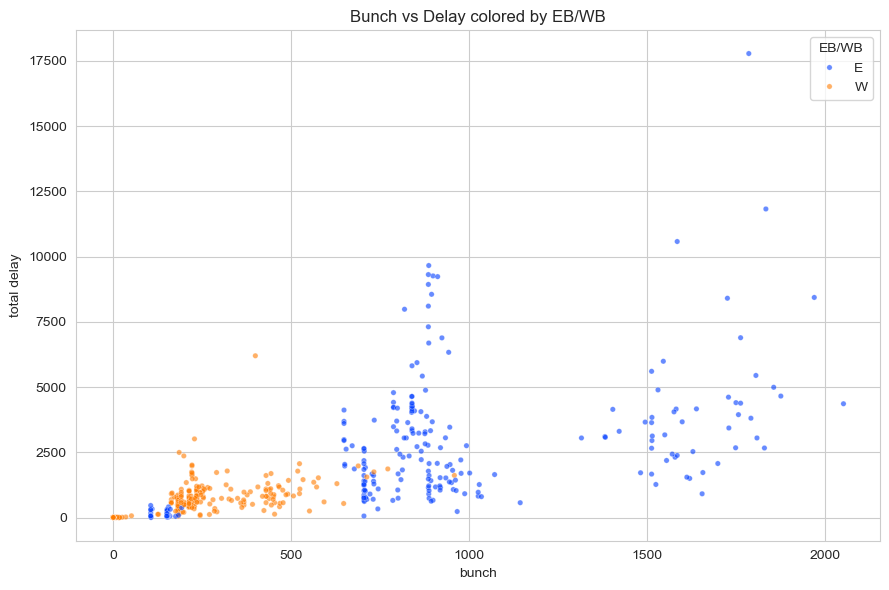

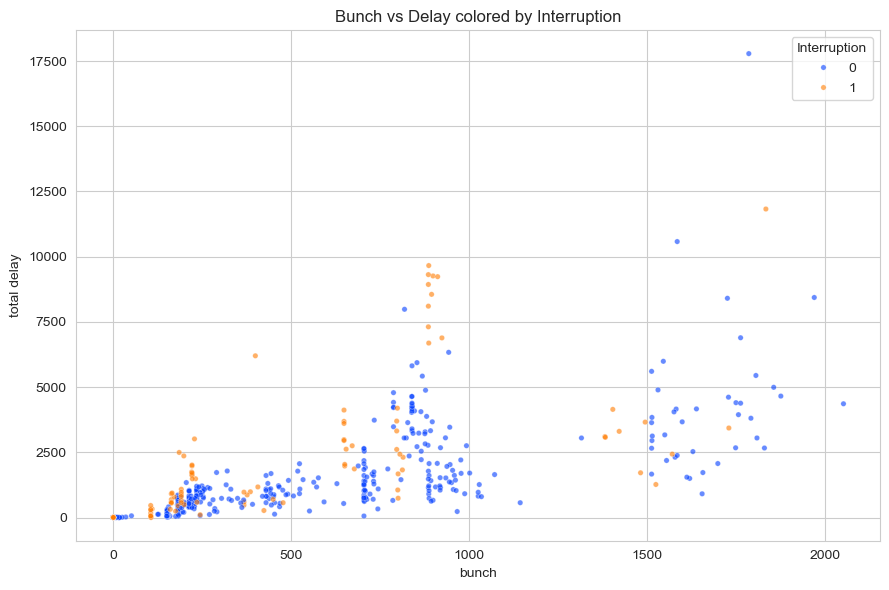

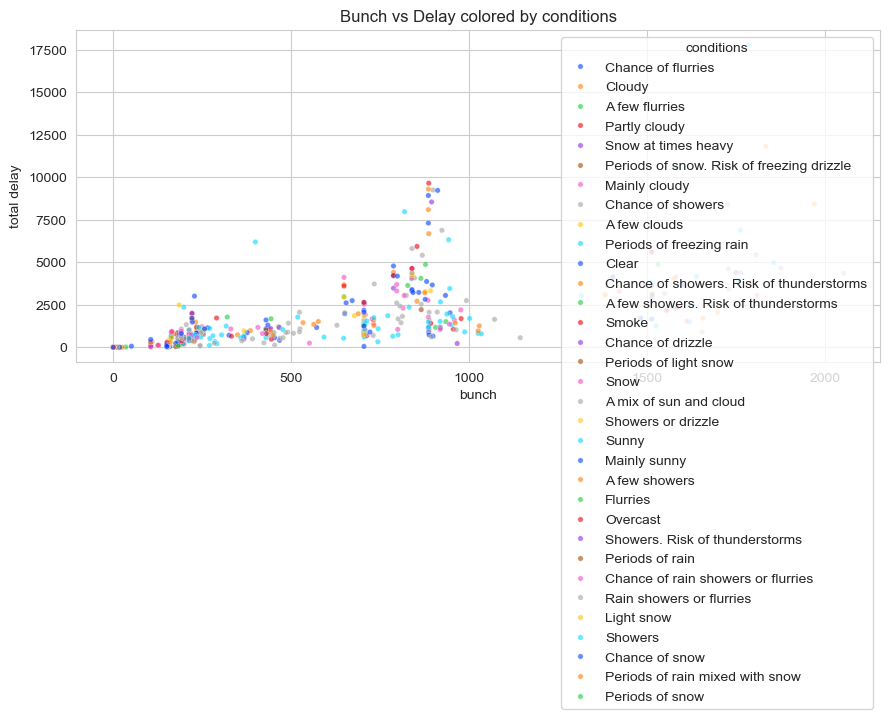

In [500]:
for hue_col in cat_features:
    plt.figure(figsize=(9,6))
    sns.scatterplot(
        data=sun_df,
        x="bunch",
        y="total delay",
        hue=hue_col,
        palette="bright",
        alpha=0.6,
        s=15
    )

    #plt.yscale("log")
    #plt.xscale("log")
    plt.title(f"Bunch vs Delay colored by {hue_col}")
    plt.xlabel("bunch")
    plt.ylabel("total delay")


    plt.tight_layout()
    plt.show()
    plt.close()

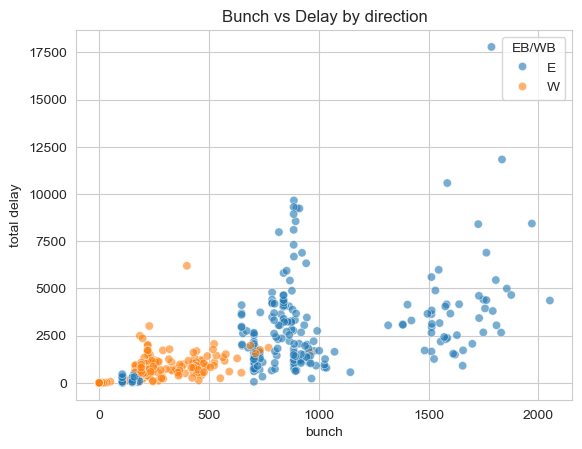

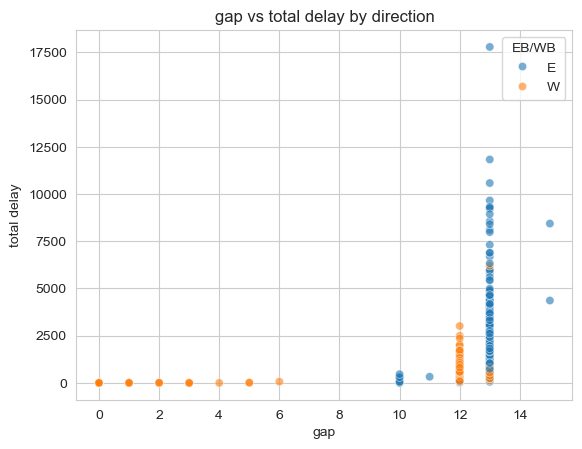

In [482]:
sns.scatterplot(
    data=sun_df,
    x="bunch",
    y="total delay",
    hue='EB/WB',
    alpha=0.6
)

plt.title("Bunch vs Delay by direction")
plt.show()

## This looks like a very similar clustering pattern as we saw with the bunch and gap 

sns.scatterplot(
    data=sun_df,
    x="gap",
    y="total delay",
    hue='EB/WB',
    alpha=0.6
)

plt.title("gap vs total delay by direction")
plt.show()


In [483]:
#Let's do a baseline model where the delay time is calculated as the average delay for a time period on a given day 
X = sun_df[features]
y = sun_df['total delay']
groups = sun_df['date']


G_kfold = GroupKFold(n_splits=5)
splits = list(G_kfold.split(X, y, groups=groups))  

mses = []
maes = []
rmses = []

for fold, (train_index, test_index) in enumerate(splits, 1):    
    X_train, X_test = X.iloc[train_index].copy(), X.iloc[test_index].copy()
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]


    temp_train = pd.concat([X_train[["time_period"]], y_train.rename("total delay")], axis=1)
    mean_by_period = temp_train.groupby("time_period")['total delay'].mean()
    y_pred = X_test["time_period"].map(mean_by_period)

    mse = mean_squared_error(y_test, y_pred)
    mses.append(mse)

    mae = mean_absolute_error(y_test, y_pred)
    maes.append(mae)

    rmse = root_mean_squared_error(y_test, y_pred)
    rmses.append(rmse)

    test_dates = sun_df["date"].iloc[test_index].nunique()
    print(
        f"Fold {fold}: "
        f"test_dates={test_dates}, "
        f"MSE={mse:.2f},"
        f"MAE={mae:.2f}, "
        f"RMSE={rmse:.2f} "
    )

print(f"Mean MSE={np.mean(mses):.2f}")
print(f"Mean MAE={np.mean(maes):.2f}")
print(f"Mean RMSE={np.mean(rmses):.2f}")

Fold 1: test_dates=10, MSE=2929956.60,MAE=1098.62, RMSE=1711.71 
Fold 2: test_dates=10, MSE=2377515.62,MAE=979.81, RMSE=1541.92 
Fold 3: test_dates=10, MSE=2143627.27,MAE=978.70, RMSE=1464.11 
Fold 4: test_dates=10, MSE=3264253.94,MAE=1147.67, RMSE=1806.72 
Fold 5: test_dates=10, MSE=4569223.04,MAE=1170.02, RMSE=2137.57 
Mean MSE=3056915.29
Mean MAE=1074.96
Mean RMSE=1732.41


In [484]:
## Now let's try a basic linear regression model and compare 
mses = []
maes = []
rmses = []

linear = LinearRegression()
for fold, (train_index, test_index) in enumerate(splits, 1):    
    X_train, X_test = X.iloc[train_index].copy(), X.iloc[test_index].copy()
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # One-hot encode
    X_train = pd.get_dummies(X_train, drop_first=False)
    X_test  = pd.get_dummies(X_test,  drop_first=False)

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

   
    #fit and predict 
    linear.fit(X_train, y_train)
    y_pred = linear.predict(X_test)


    mse = mean_squared_error(y_test, y_pred)
    mses.append(mse)

    mae = mean_absolute_error(y_test, y_pred)
    maes.append(mae)

    rmse = root_mean_squared_error(y_test, y_pred)
    rmses.append(rmse)

    test_dates = sun_df["date"].iloc[test_index].nunique()
    print(
        f"Fold {fold}: "
        f"test_dates={test_dates}, "
        f"MSE={mse:.2f},"
        f"MAE={mae:.2f}, "
        f"RMSE={rmse:.2f} "
    )

print(f"Mean MSE={np.mean(mses):.2f}")
print(f"Mean MAE={np.mean(maes):.2f}")
print(f"Mean RMSE={np.mean(rmses):.2f}")



Fold 1: test_dates=10, MSE=1961586.43,MAE=965.40, RMSE=1400.57 
Fold 2: test_dates=10, MSE=1495946.77,MAE=831.54, RMSE=1223.09 
Fold 3: test_dates=10, MSE=1638141.58,MAE=878.56, RMSE=1279.90 
Fold 4: test_dates=10, MSE=1823145.35,MAE=863.49, RMSE=1350.24 
Fold 5: test_dates=10, MSE=3350832.53,MAE=997.68, RMSE=1830.53 
Mean MSE=2053930.53
Mean MAE=907.33
Mean RMSE=1416.86


In [485]:
## Lets take a look, I suspect we are over fitting right now, in particular with the weather data 

coef = pd.Series(linear.coef_, index=X_train.columns)
coef.sort_values().tail(10)

conditions_A mix of sun and cloud                   332.105873
conditions_Clear                                    334.587028
conditions_Sunny                                    374.645993
conditions_A few flurries                           386.053982
time_period                                         427.718894
conditions_Periods of freezing rain                 545.641001
conditions_Partly cloudy                            674.559076
conditions_Cloudy                                   847.873778
conditions_A few showers. Risk of thunderstorms    1111.194319
Interruption                                       1351.828162
dtype: float64

In [486]:
# Lets try to refine this weather feature a bit by grouping the different weather conditions

def weather_group(cond):
    cond = str(cond).lower()
    if "snow" in cond or "flurr" in cond or "freez" in cond:
        return "snow"
    elif "rain" in cond or "shower" in cond or "drizzle" in cond or "thunder" in cond:
        return "rain"
    else:
        return "other"
    
sun_df["weather_group"] = sun_df["conditions"].apply(weather_group)
sun_df["weather_group"].value_counts()

weather_group
other    310
snow     104
rain      86
Name: count, dtype: int64

In [487]:
features_new = num_features + ['time_period','EB/WB','Interruption','weather_group']
X_new = sun_df[features_new]

In [488]:
# Run the Linear regression again
## Now let's try a basic linear regression model and compare 
mses = []
maes = []
rmses = []

linear = LinearRegression()
for fold, (train_index, test_index) in enumerate(G_kfold.split(X_new, y, groups=groups), 1):
    X_train, X_test = X_new.iloc[train_index].copy(), X_new.iloc[test_index].copy()
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # One-hot encode
    X_train = pd.get_dummies(X_train, drop_first=False)
    X_test  = pd.get_dummies(X_test,  drop_first=False)

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

   
    #fit and predict 
    linear.fit(X_train, y_train)
    y_pred = linear.predict(X_test)


    mse = mean_squared_error(y_test, y_pred)
    mses.append(mse)

    mae = mean_absolute_error(y_test, y_pred)
    maes.append(mae)

    rmse = root_mean_squared_error(y_test, y_pred)
    rmses.append(rmse)

    test_dates = sun_df["date"].iloc[test_index].nunique()
    print(
        f"Fold {fold}: "
        f"test_dates={test_dates}, "
        f"MSE={mse:.2f},"
        f"MAE={mae:.2f}, "
        f"RMSE={rmse:.2f} "
    )

print(f"Mean MSE={np.mean(mses):.2f}")
print(f"Mean MAE={np.mean(maes):.2f}")
print(f"Mean RMSE={np.mean(rmses):.2f}")



Fold 1: test_dates=10, MSE=1948522.22,MAE=918.52, RMSE=1395.89 
Fold 2: test_dates=10, MSE=1375398.86,MAE=775.30, RMSE=1172.77 
Fold 3: test_dates=10, MSE=1583375.81,MAE=855.39, RMSE=1258.32 
Fold 4: test_dates=10, MSE=1747482.95,MAE=810.14, RMSE=1321.92 
Fold 5: test_dates=10, MSE=3109197.97,MAE=897.88, RMSE=1763.29 
Mean MSE=1952795.56
Mean MAE=851.45
Mean RMSE=1382.44


In [489]:
coef = pd.Series(linear.coef_, index=X_train.columns)
coef.sort_values().tail(10)

EB/WB_W                -306.656092
weather_group_snow     -144.486022
gap                     -66.747208
weather_group_rain      -31.205023
temperature              -3.146887
bunch                     2.107964
weather_group_other     175.691045
EB/WB_E                 306.656092
time_period             447.047595
Interruption           1178.795866
dtype: float64

In [ ]:
## Next try to transform the columns and scale before fitting the model. In particular, look at the scatterplot with the log scaling, consider the time of day vs E/W clustering that seems to create two seperate groupings in the time of day scatterplot which might coencide with E/W  